[*********************100%***********************]  5 of 5 completed
/tmp/ipykernel_1143/3722257698.py:37: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change().dropna()



Inverse Volatility Portfolio Weights
Ticker
GOLDBEES.NS    0.304025
HDFCBANK.NS    0.156114
RELIANCE.NS    0.143162
TCS.NS         0.173942
^NSEI          0.222757
dtype: float64

Performance Metrics
Annual Return     : 14.79%
Annual Volatility : 14.47%
Sharpe Ratio      : 1.02


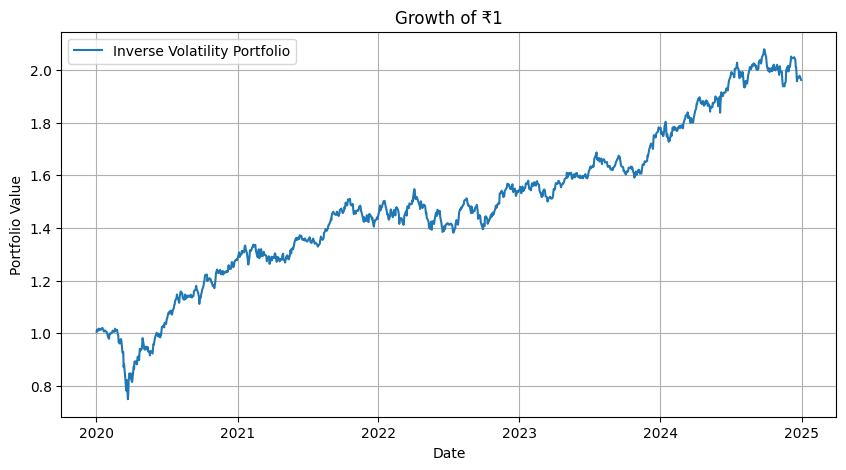

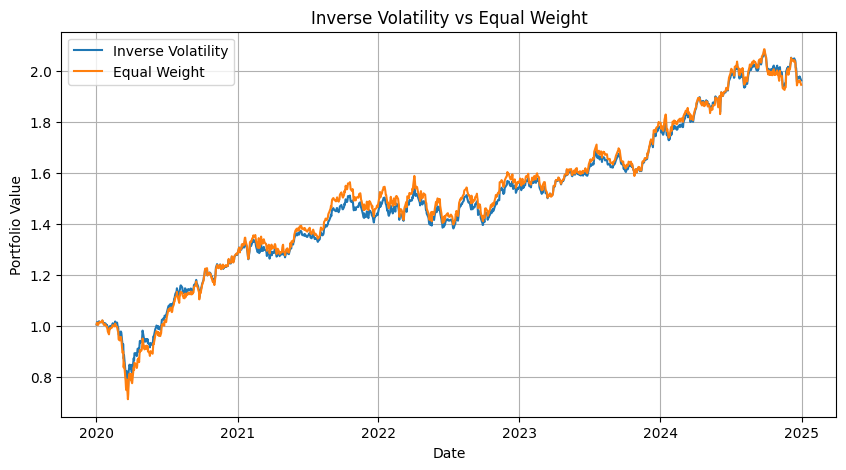

In [1]:
# ==========================================
# Inverse Volatility Portfolio
# ==========================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Assets
# ==========================================

assets = [
    "^NSEI",
    "GOLDBEES.NS",
    "HDFCBANK.NS",
    "RELIANCE.NS",
    "TCS.NS"
]

# ==========================================
# Download Data
# ==========================================

prices = yf.download(
    assets,
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=True
)["Close"]

# ==========================================
# Daily Returns
# ==========================================

returns = prices.pct_change().dropna()

# ==========================================
# Annualized Volatility
# ==========================================

volatility = returns.std() * np.sqrt(252)

# ==========================================
# Inverse Volatility Weights
# ==========================================

inverse_vol = 1 / volatility
weights = inverse_vol / inverse_vol.sum()

print("\nInverse Volatility Portfolio Weights")
print(weights)

# ==========================================
# Portfolio Returns
# ==========================================

portfolio_returns = (returns * weights).sum(axis=1)

# ==========================================
# Performance Metrics
# ==========================================

annual_return = portfolio_returns.mean() * 252
annual_volatility = portfolio_returns.std() * np.sqrt(252)
sharpe_ratio = annual_return / annual_volatility

print("\nPerformance Metrics")
print(f"Annual Return     : {annual_return:.2%}")
print(f"Annual Volatility : {annual_volatility:.2%}")
print(f"Sharpe Ratio      : {sharpe_ratio:.2f}")

# ==========================================
# Growth of ₹1
# ==========================================

cumulative = (1 + portfolio_returns).cumprod()

plt.figure(figsize=(10,5))
plt.plot(cumulative, label="Inverse Volatility Portfolio")
plt.title("Growth of ₹1")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# Compare with Equal Weight Portfolio
# ==========================================

equal_weights = np.repeat(1/len(assets), len(assets))
equal_returns = (returns * equal_weights).sum(axis=1)

comparison = pd.DataFrame({
    "Inverse Volatility": (1 + portfolio_returns).cumprod(),
    "Equal Weight": (1 + equal_returns).cumprod()
})

plt.figure(figsize=(10,5))
plt.plot(comparison["Inverse Volatility"], label="Inverse Volatility")
plt.plot(comparison["Equal Weight"], label="Equal Weight")
plt.title("Inverse Volatility vs Equal Weight")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.show()


Performance Comparison
                   Inverse Volatility  NIFTY 50
CAGR                         0.147223  0.144645
Annual Volatility            0.144663  0.191074
Sharpe Ratio                 1.017694  0.757011
Sortino Ratio                1.267265  0.852913
Max Drawdown                -0.265952 -0.384399
Calmar Ratio                 0.553570  0.376289
VaR (95%)                   -0.012210 -0.016299
CVaR (95%)                  -0.020244 -0.029456


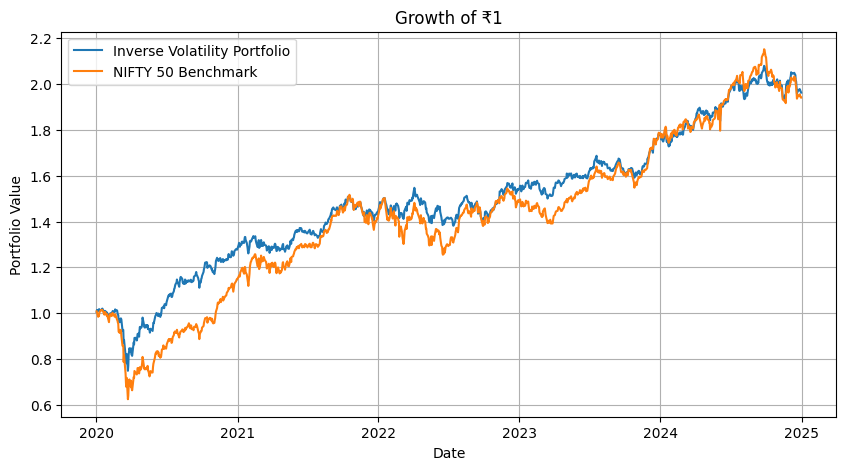

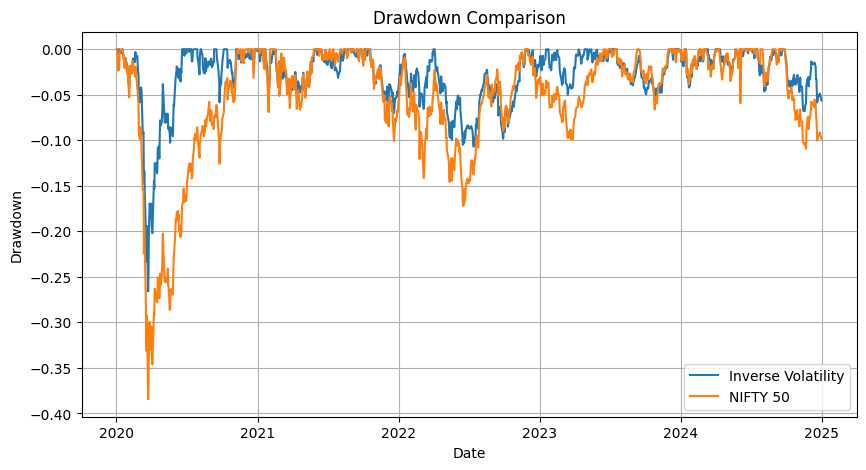

In [2]:
# ==========================================
# Benchmark (NIFTY 50)
# ==========================================

benchmark_returns = returns["^NSEI"]

# ==========================================
# Performance Metrics Function
# ==========================================

def performance_metrics(r):

    annual_return = (1 + r).prod()**(252/len(r)) - 1
    annual_volatility = r.std() * np.sqrt(252)

    sharpe = annual_return / annual_volatility

    downside = r[r < 0].std() * np.sqrt(252)
    sortino = annual_return / downside

    cumulative = (1 + r).cumprod()
    running_max = cumulative.cummax()
    drawdown = cumulative / running_max - 1

    max_drawdown = drawdown.min()

    calmar = annual_return / abs(max_drawdown)

    var95 = np.percentile(r, 5)
    cvar95 = r[r <= var95].mean()

    return {
        "CAGR": annual_return,
        "Annual Volatility": annual_volatility,
        "Sharpe Ratio": sharpe,
        "Sortino Ratio": sortino,
        "Max Drawdown": max_drawdown,
        "Calmar Ratio": calmar,
        "VaR (95%)": var95,
        "CVaR (95%)": cvar95
    }

# ==========================================
# Compare Portfolio vs Benchmark
# ==========================================

portfolio_stats = performance_metrics(portfolio_returns)
benchmark_stats = performance_metrics(benchmark_returns)

comparison = pd.DataFrame({
    "Inverse Volatility": portfolio_stats,
    "NIFTY 50": benchmark_stats
})

print("\nPerformance Comparison")
print(comparison)

# ==========================================
# Growth Comparison
# ==========================================

portfolio_growth = (1 + portfolio_returns).cumprod()
benchmark_growth = (1 + benchmark_returns).cumprod()

plt.figure(figsize=(10,5))
plt.plot(portfolio_growth, label="Inverse Volatility Portfolio")
plt.plot(benchmark_growth, label="NIFTY 50 Benchmark")
plt.title("Growth of ₹1")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# Drawdown Comparison
# ==========================================

portfolio_dd = portfolio_growth / portfolio_growth.cummax() - 1
benchmark_dd = benchmark_growth / benchmark_growth.cummax() - 1

plt.figure(figsize=(10,5))
plt.plot(portfolio_dd, label="Inverse Volatility")
plt.plot(benchmark_dd, label="NIFTY 50")
plt.title("Drawdown Comparison")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.show()